In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def show(img, title="", cmap="gray", size=(5,5)):
    plt.figure(figsize=size)
    plt.imshow(img, cmap=cmap)
    plt.title(title)
    plt.axis('off')
    plt.show()

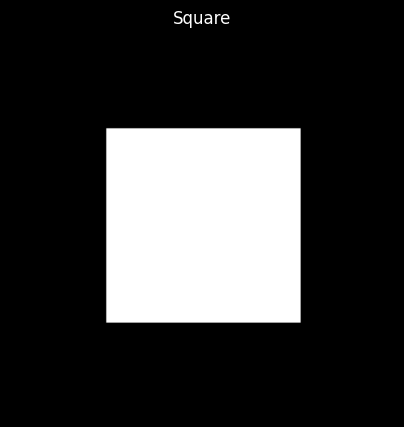

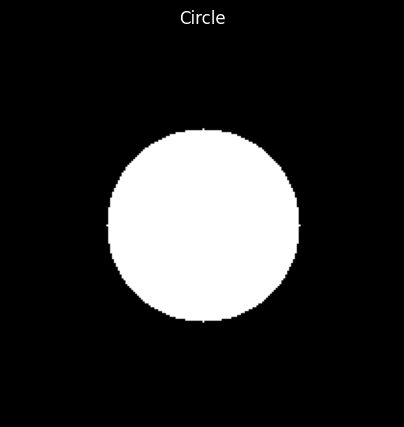

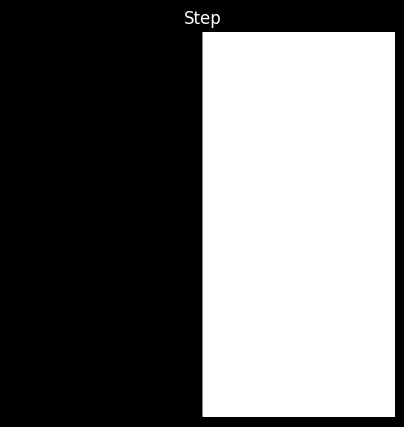

In [2]:
square = np.zeros((200,200), dtype=np.uint8)
circle = np.zeros((200,200), dtype=np.uint8)
step = np.zeros((200,200), dtype=np.uint8)

cv2.rectangle(square, (50,50), (150,150), 255, -1)
cv2.circle(circle, (100,100), 50, 255, -1)
step[:, :100] = 50
step[:, 100:] = 220

show(square, "Square")
show(circle, "Circle")
show(step, "Step")

## Topic 1: Simple Image Gradients

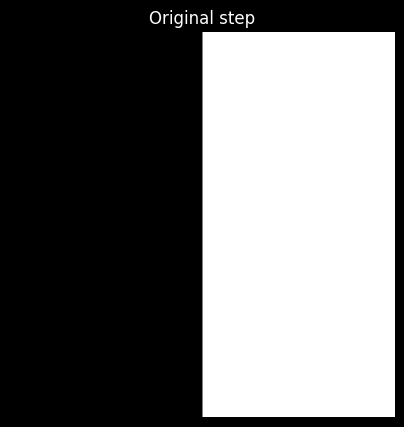

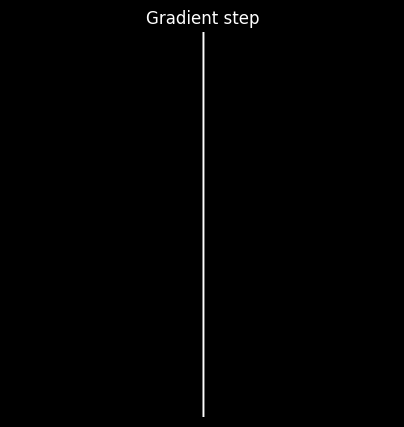

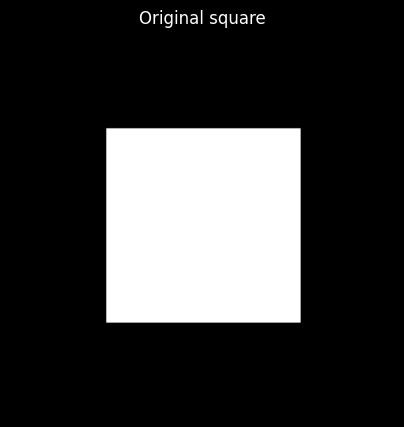

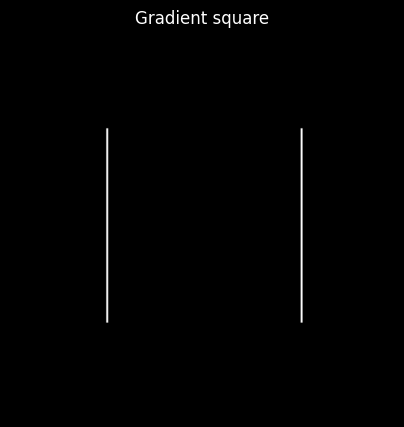

In [3]:
kernel_x = np.array([[-1, 1]], dtype=np.float32)

grad_step = cv2.filter2D(step, cv2.CV_64F, kernel_x)
grad_square = cv2.filter2D(square, cv2.CV_64F, kernel_x)

show(step, "Original step")
show(np.abs(grad_step).astype(np.uint8), "Gradient step")
show(square, "Original square")
show(np.abs(grad_square).astype(np.uint8), "Gradient square")

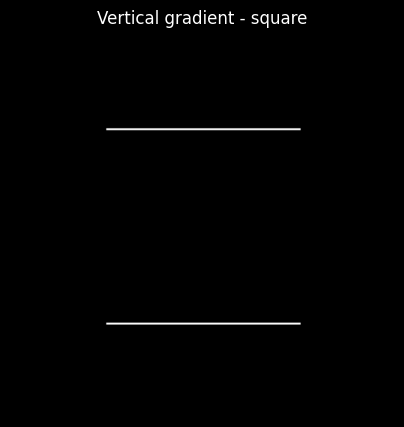

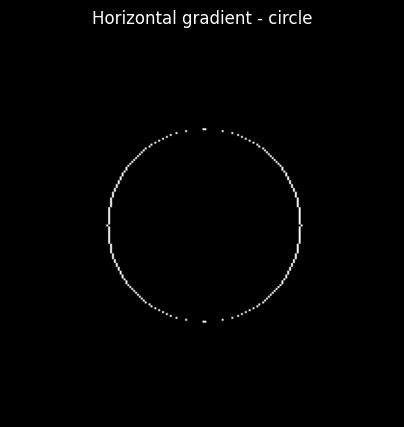

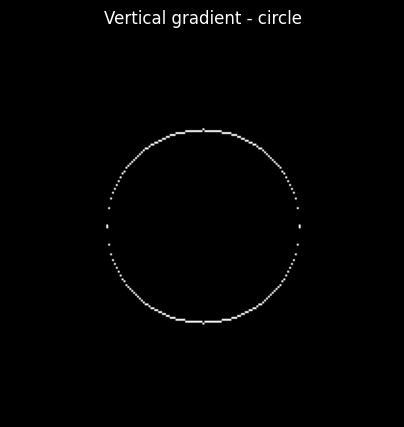

In [4]:
kernel_y = np.array([[-1], [1]], dtype=np.float32)

grad_square_y = cv2.filter2D(square, cv2.CV_64F, kernel_y)
grad_circle_x = cv2.filter2D(circle, cv2.CV_64F, kernel_x)
grad_circle_y = cv2.filter2D(circle, cv2.CV_64F, kernel_y)

show(np.abs(grad_square_y).astype(np.uint8), "Vertical gradient - square")
show(np.abs(grad_circle_x).astype(np.uint8), "Horizontal gradient - circle")
show(np.abs(grad_circle_y).astype(np.uint8), "Vertical gradient - circle")

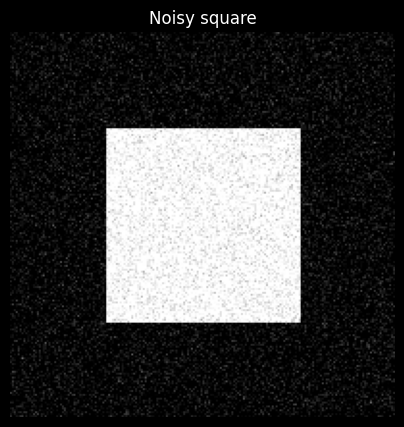

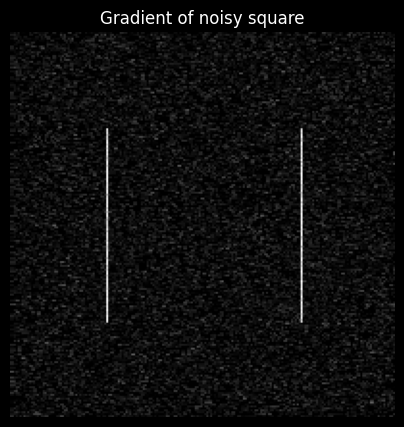

In [5]:
rng = np.random.default_rng(42)
noisy_square = np.clip(square + rng.normal(0, 25, square.shape), 0, 255).astype(np.uint8)
grad_noisy = cv2.filter2D(noisy_square, cv2.CV_64F, kernel_x)

show(noisy_square, "Noisy square")
show(np.abs(grad_noisy).astype(np.uint8), "Gradient of noisy square")

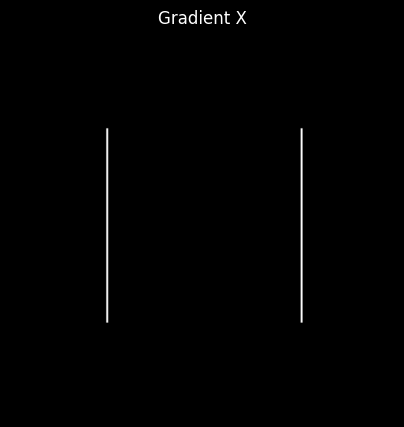

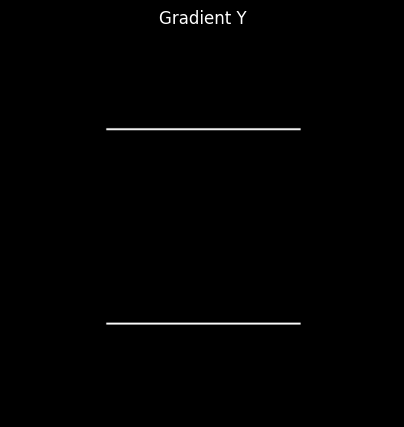

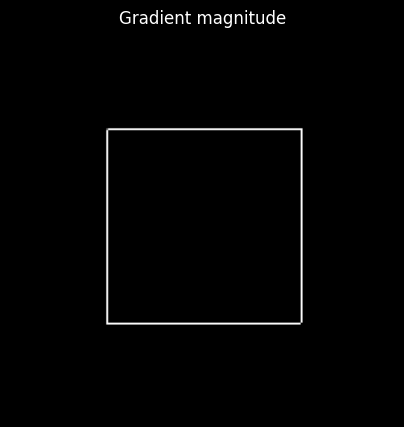

In [6]:
def simple_gradient(image, direction='x'):
    if direction == 'x':
        kernel = np.array([[-1, 1]], dtype=np.float32)
    else:
        kernel = np.array([[-1], [1]], dtype=np.float32)
    return cv2.filter2D(image, cv2.CV_64F, kernel)

gx = simple_gradient(square, 'x')
gy = simple_gradient(square, 'y')
magnitude = np.sqrt(gx**2 + gy**2)

show(np.abs(gx).astype(np.uint8), "Gradient X")
show(np.abs(gy).astype(np.uint8), "Gradient Y")
show(magnitude.astype(np.uint8), "Gradient magnitude")

## Topic 2: Sobel Edge Detector

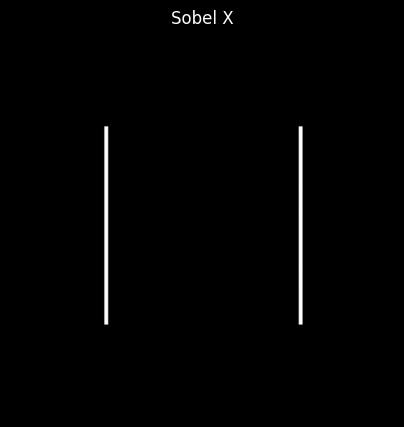

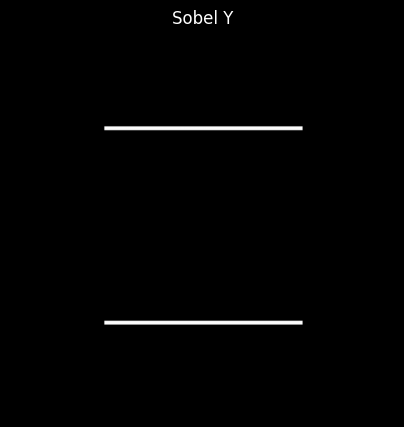

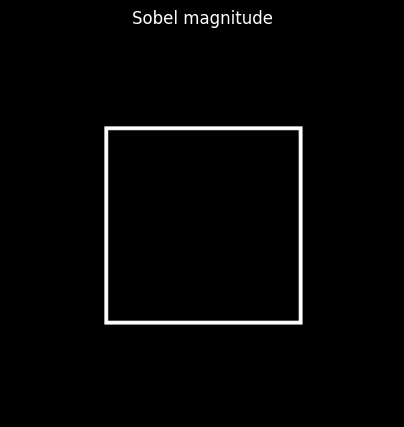

In [7]:
sobel_x = cv2.Sobel(square, cv2.CV_64F, 1, 0, ksize=3)
sobel_y = cv2.Sobel(square, cv2.CV_64F, 0, 1, ksize=3)
sobel_mag = np.sqrt(sobel_x**2 + sobel_y**2)
sobel_mag = np.clip(sobel_mag, 0, 255).astype(np.uint8)

show(np.abs(sobel_x).astype(np.uint8), "Sobel X")
show(np.abs(sobel_y).astype(np.uint8), "Sobel Y")
show(sobel_mag, "Sobel magnitude")

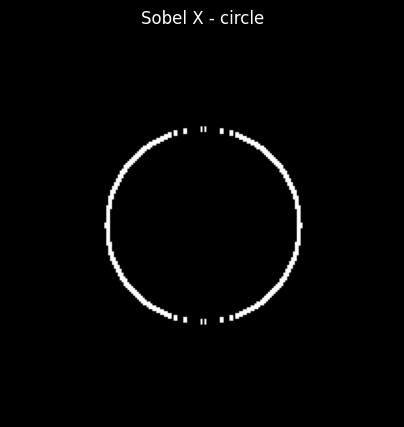

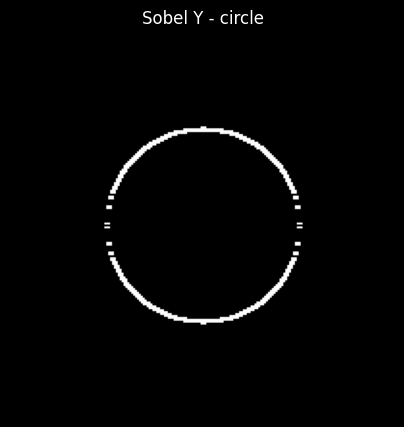

In [8]:
sobel_circ_x = cv2.Sobel(circle, cv2.CV_64F, 1, 0, ksize=3)
sobel_circ_y = cv2.Sobel(circle, cv2.CV_64F, 0, 1, ksize=3)

show(np.abs(sobel_circ_x).astype(np.uint8), "Sobel X - circle")
show(np.abs(sobel_circ_y).astype(np.uint8), "Sobel Y - circle")

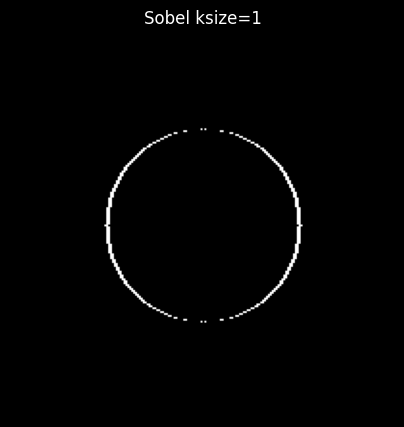

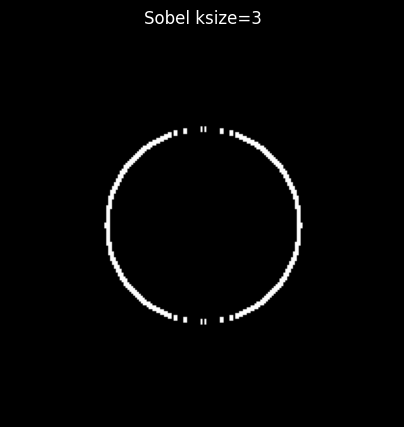

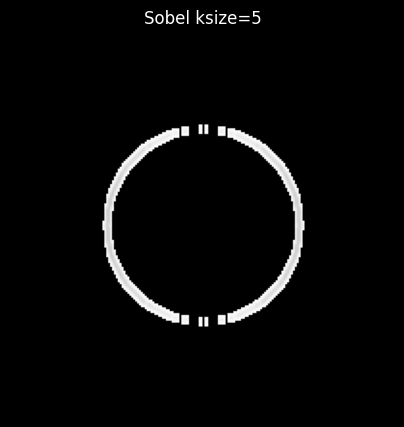

In [9]:
for k in [1, 3, 5]:
    sobel_k = cv2.Sobel(circle, cv2.CV_64F, 1, 0, ksize=k)
    show(np.abs(sobel_k).astype(np.uint8), f"Sobel ksize={k}")

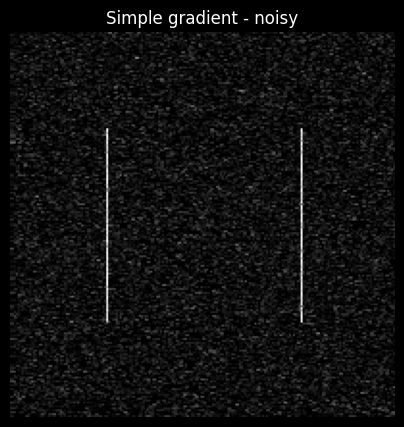

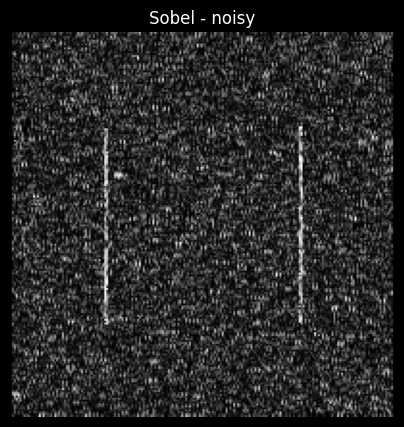

In [10]:
noisy_square = np.clip(square + rng.normal(0, 30, square.shape), 0, 255).astype(np.uint8)
grad_simple = cv2.filter2D(noisy_square, cv2.CV_64F, kernel_x)
sobel_noisy = cv2.Sobel(noisy_square, cv2.CV_64F, 1, 0, ksize=3)

show(np.abs(grad_simple).astype(np.uint8), "Simple gradient - noisy")
show(np.abs(sobel_noisy).astype(np.uint8), "Sobel - noisy")

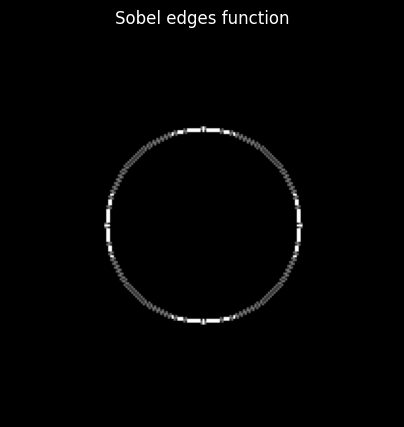

In [11]:
def sobel_edges(image, ksize=3):
    gx = cv2.Sobel(image, cv2.CV_64F, 1, 0, ksize=ksize)
    gy = cv2.Sobel(image, cv2.CV_64F, 0, 1, ksize=ksize)
    mag = np.sqrt(gx**2 + gy**2)
    return gx, gy, mag

gx, gy, mag = sobel_edges(circle, ksize=3)
show(mag.astype(np.uint8), "Sobel edges function")

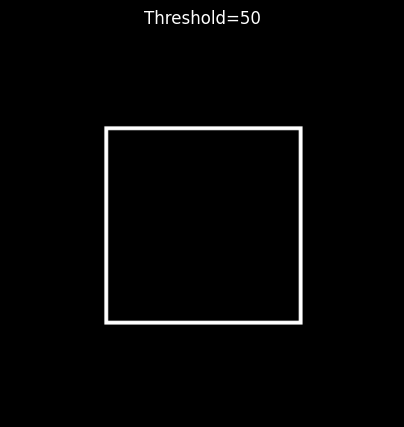

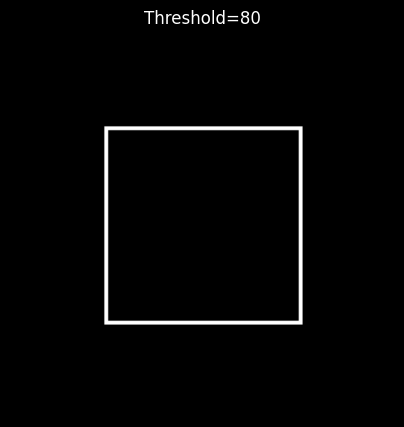

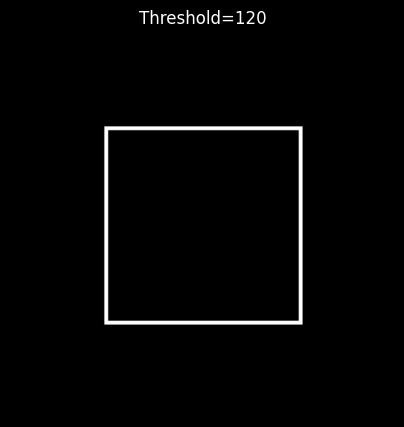

In [12]:
for thresh in [50, 80, 120]:
    binary = (sobel_mag > thresh).astype(np.uint8) * 255
    show(binary, f"Threshold={thresh}")

## Topic 3: Laplacian Edge Detector

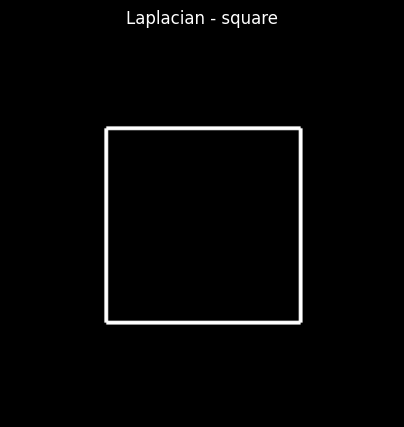

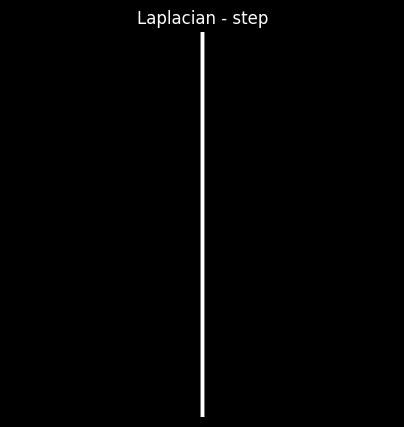

In [13]:
lap_square = cv2.Laplacian(square, cv2.CV_64F)
lap_step = cv2.Laplacian(step, cv2.CV_64F)

show(np.abs(lap_square).astype(np.uint8), "Laplacian - square")
show(np.abs(lap_step).astype(np.uint8), "Laplacian - step")

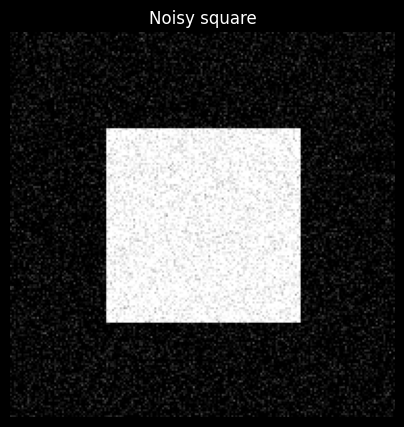

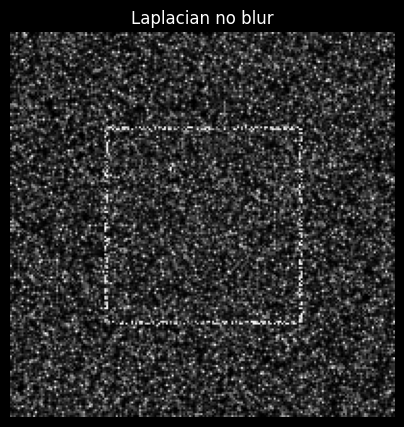

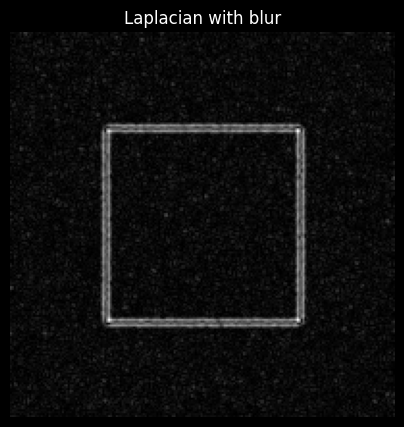

In [14]:
noisy_sq = np.clip(square + rng.normal(0, 25, square.shape), 0, 255).astype(np.uint8)
lap_no_blur = cv2.Laplacian(noisy_sq, cv2.CV_64F)
blurred = cv2.GaussianBlur(noisy_sq, (5,5), 0)
lap_blur = cv2.Laplacian(blurred, cv2.CV_64F)

show(noisy_sq, "Noisy square")
show(np.abs(lap_no_blur).astype(np.uint8), "Laplacian no blur")
show(np.abs(lap_blur).astype(np.uint8), "Laplacian with blur")

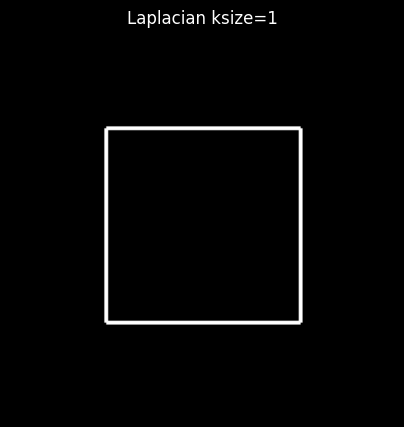

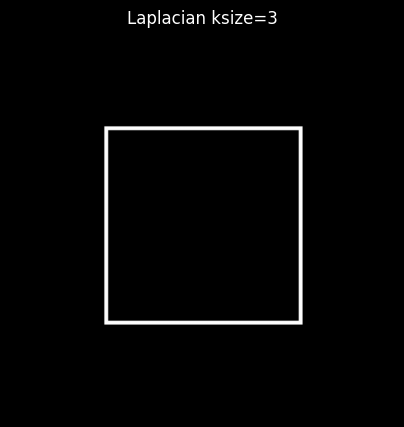

In [15]:
for k in [1, 3]:
    lap_k = cv2.Laplacian(square, cv2.CV_64F, ksize=k)
    show(np.abs(lap_k).astype(np.uint8), f"Laplacian ksize={k}")

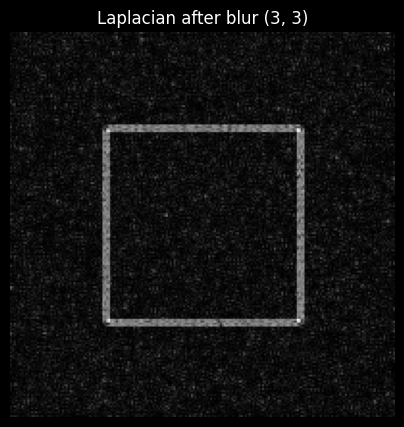

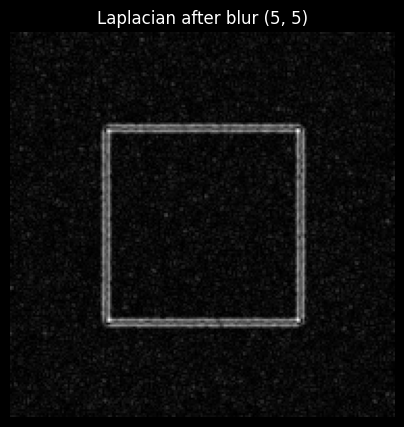

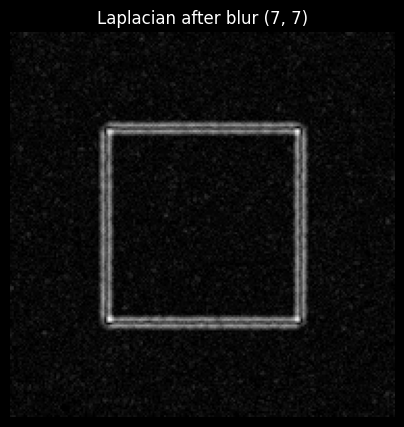

In [16]:
for ks in [(3,3), (5,5), (7,7)]:
    blur_img = cv2.GaussianBlur(noisy_sq, ks, 0)
    lap = cv2.Laplacian(blur_img, cv2.CV_64F)
    show(np.abs(lap).astype(np.uint8), f"Laplacian after blur {ks}")

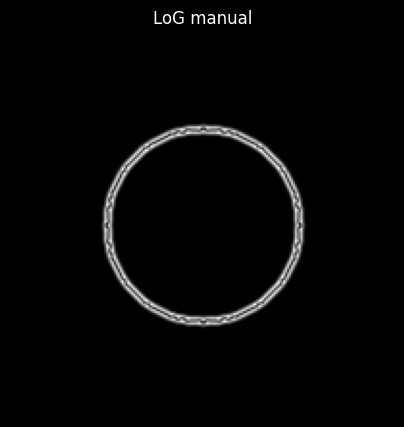

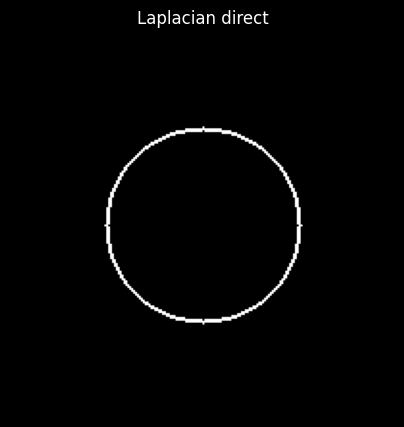

In [17]:
blur_manual = cv2.GaussianBlur(circle, (5,5), 0)
log_manual = cv2.Laplacian(blur_manual, cv2.CV_64F)
log_direct = cv2.Laplacian(circle, cv2.CV_64F)

show(np.abs(log_manual).astype(np.uint8), "LoG manual")
show(np.abs(log_direct).astype(np.uint8), "Laplacian direct")

## Topic 4: Canny Edge Detector

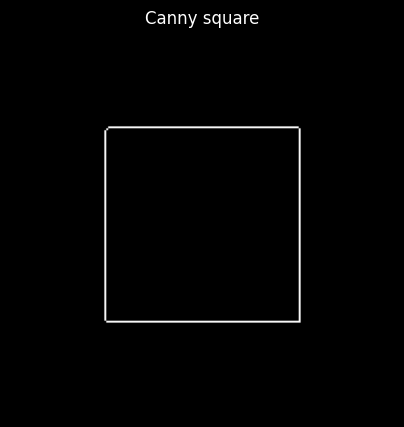

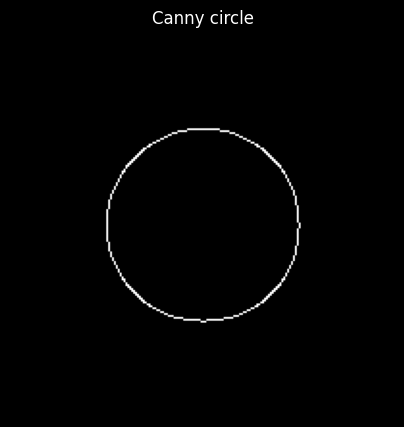

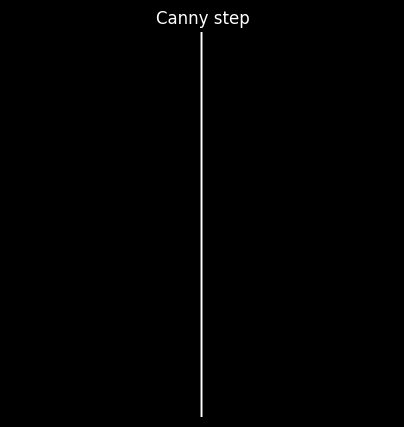

In [18]:
edges_square = cv2.Canny(square, 50, 150)
edges_circle = cv2.Canny(circle, 50, 150)
edges_step = cv2.Canny(step, 50, 150)

show(edges_square, "Canny square")
show(edges_circle, "Canny circle")
show(edges_step, "Canny step")

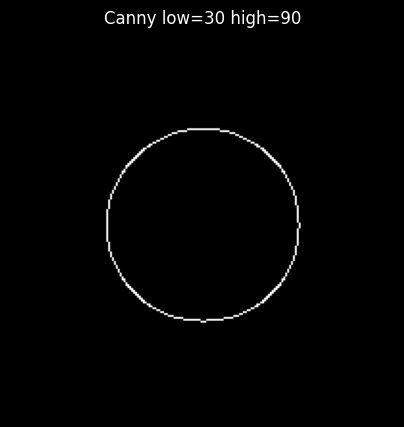

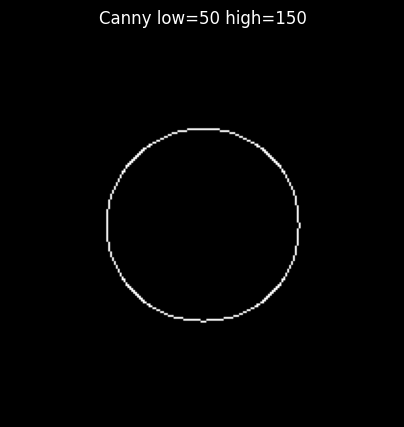

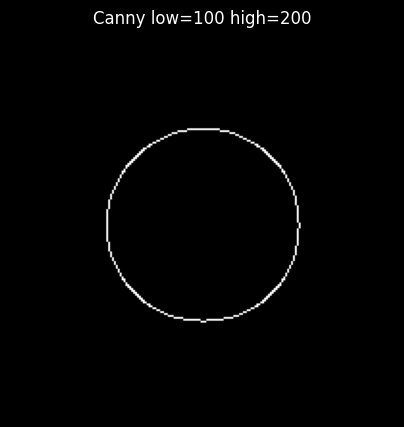

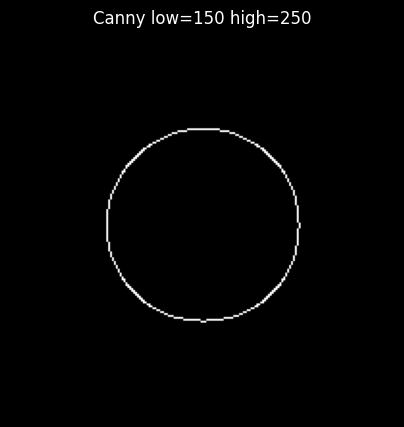

In [19]:
pairs = [(30, 90), (50, 150), (100, 200), (150, 250)]
for low, high in pairs:
    edges = cv2.Canny(circle, low, high)
    show(edges, f"Canny low={low} high={high}")

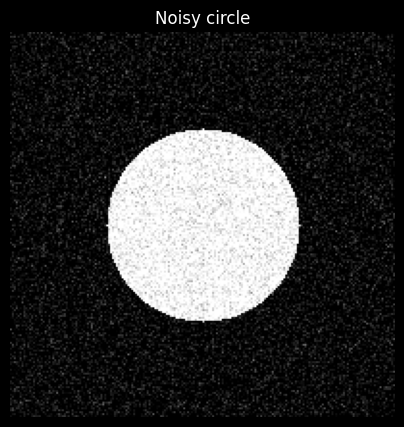

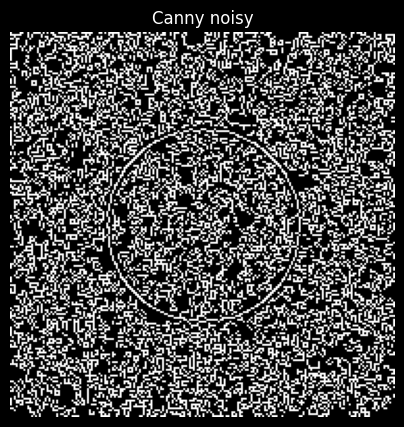

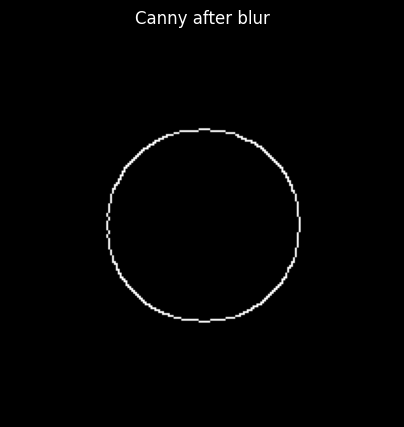

In [20]:
noisy_circle = np.clip(circle + rng.normal(0, 30, circle.shape), 0, 255).astype(np.uint8)
canny_noisy = cv2.Canny(noisy_circle, 50, 150)
canny_blurred = cv2.Canny(cv2.GaussianBlur(noisy_circle, (5,5), 0), 50, 150)

show(noisy_circle, "Noisy circle")
show(canny_noisy, "Canny noisy")
show(canny_blurred, "Canny after blur")

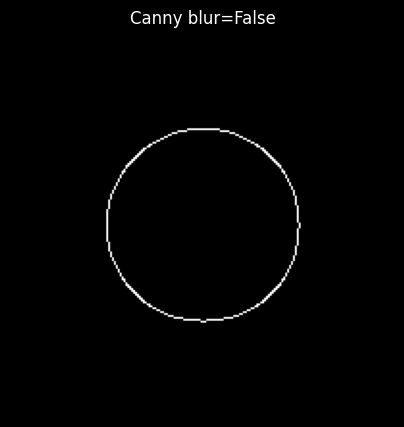

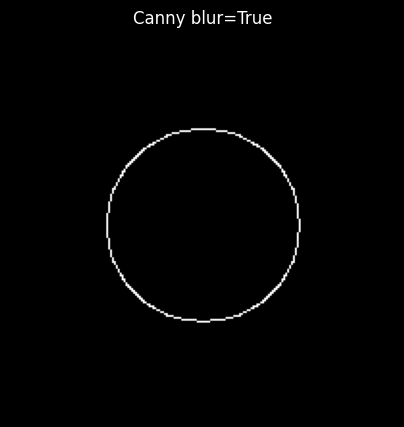

In [21]:
def run_canny(image, low, high, blur=False):
    if blur:
        image = cv2.GaussianBlur(image, (5,5), 0)
    return cv2.Canny(image, low, high)

for blur in [False, True]:
    result = run_canny(circle, 50, 150, blur)
    show(result, f"Canny blur={blur}")

## Comparison Summary

| Method | Main idea | Strength | Weakness |
|---|---|---|---|
| Simple gradient | Difference between neighbours | Easy to understand | Sensitive, limited |
| Sobel | Gradient + smoothing | More stable than basic gradient | Still may respond to noise |
| Laplacian | Second derivative | Detects edges in all directions | Very noise-sensitive |
| Canny | Multi-stage edge detector | Clean, thin, practical edges | Needs parameter tuning |